In [ ]:
import kagglehub

path = kagglehub.dataset_download("gauravsharma99/fer13-cleaned-dataset")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fer13-cleaned-dataset' dataset.
Path to dataset files: /kaggle/input/fer13-cleaned-dataset


In [ ]:
import os
import cv2
import numpy as np

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
IMG_SIZE = 224

label_map = {
    "angry": 0,
    "disgust": 1,
    "fear": 2,
    "happy": 3,
    "neutral": 4
}

In [ ]:
def load_data(path):
    data = []
    labels = []

    for folder_name in os.listdir(path):
        folder_path = os.path.join(path, folder_name)

        if not os.path.isdir(folder_path):
            continue

        label_name = folder_name.lower()

        if label_name not in label_map:
            continue

        label = label_map[label_name]

        print("Loading:", folder_name)

        for img_name in os.listdir(folder_path):
            img_path = os.path.join(folder_path, img_name)

            img = cv2.imread(img_path)
            if img is None:
                continue

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            data.append(img)
            labels.append(label)

    return np.array(data), np.array(labels)

In [ ]:
print(os.listdir(path))

['fear', 'Angry', 'Neutral', 'disgust', 'Happy']


In [ ]:
X, y = load_data(path)

Loading: fear
Loading: Angry
Loading: Neutral
Loading: disgust
Loading: Happy


In [ ]:

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (16876, 224, 224, 3)
y shape: (16876,)


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

IMG_SIZE = 160
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,

    # ✅ safer augmentation
    rotation_range=15,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8,1.2]
)

In [ ]:
train_data = datagen.flow_from_directory(
    path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True   # ✅ important
)

val_data = datagen.flow_from_directory(
    path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False  # ✅ important
)

Found 13502 images belonging to 5 classes.
Found 3374 images belonging to 5 classes.


In [ ]:
print(train_data.class_indices)

{'Angry': 0, 'Happy': 1, 'Neutral': 2, 'disgust': 3, 'fear': 4}


In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model

IMG_SIZE = 160

base_model = EfficientNetB0(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# ✅ REMOVE full freeze
# ❌ DO NOT USE THIS:
# for layer in base_model.layers:
#     layer.trainable = False

# ✅ USE THIS ONLY (partial freeze)
for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)

# ✅ simplified + better learning
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

output = Dense(5, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

In [ ]:

model.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss='categorical_crossentropy',  # keep ONLY if class_mode='categorical'
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

callbacks = [
    ModelCheckpoint(
        '/content/drive/MyDrive/best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
]

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=12,
    callbacks=callbacks
)

Epoch 1/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 863ms/step - accuracy: 0.3705 - loss: 1.8283
Epoch 1: val_accuracy improved from None to 0.61440, saving model to /content/drive/MyDrive/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_model.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 461s 1s/step - accuracy: 0.4455 - loss: 1.5901 - val_accuracy: 0.6144 - val_loss: 1.0666 - learning_rate: 3.0000e-04
Epoch 2/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 867ms/step - accuracy: 0.5592 - loss: 1.1998
Epoch 2: val_accuracy improved from 0.61440 to 0.64582, saving model to /content/drive/MyDrive/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/best_model.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 443s 1s/step - accuracy: 0.5754 - loss: 1.1651 - val_accuracy: 0.6458 - val_loss: 0.9513 - learning_rate: 3.0000e-04
Epoch 3/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 870ms/step - accuracy: 0.6007 - loss: 1.0653
Epoch 3: val_accuracy improved from 0.64582 to 0.66983, saving model to /

In [ ]:
!rm -rf /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive

'Amritsar photos '  'Colab Notebooks'  'My_amritsar photos '


In [ ]:
!ls /content/drive/MyDrive

'Amritsar photos '  'Colab Notebooks'  'My_amritsar photos '


In [ ]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if 'model' in file:
            print(os.path.join(root, file))

In [ ]:
!find /content/drive -name "*.keras"

In [ ]:
model.save('/content/drive/MyDrive/best_model.keras')

In [ ]:
!ls /content/drive/MyDrive

'Amritsar photos '   best_model.keras  'Colab Notebooks'  'My_amritsar photos '


In [ ]:
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/best_model.keras')

In [ ]:
# Freeze all layers
for layer in model.layers:
    layer.trainable = False

# Unfreeze last 60 layers
for layer in model.layers[-60:]:
    layer.trainable = True

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,
    callbacks=callbacks
)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 976ms/step - accuracy: 0.7481 - loss: 0.6637
Epoch 1: val_accuracy did not improve from 0.73177
422/422 ━━━━━━━━━━━━━━━━━━━━ 506s 1s/step - accuracy: 0.7539 - loss: 0.6541 - val_accuracy: 0.7167 - val_loss: 0.7584 - learning_rate: 1.0000e-05
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7611 - loss: 0.6369
Epoch 2: val_accuracy improved from 0.73177 to 0.73385, saving model to /content/drive/MyDrive/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/best_model.keras

Epoch 2: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
422/422 ━━━━━━━━━━━━━━━━━━━━ 567s 1s/step - accuracy: 0.7577 - loss: 0.6417 - val_accuracy: 0.7338 - val_loss: 0.7293 - learning_rate: 1.0000e-05
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7589 - loss: 0.6447
Epoch 3: val_accuracy did not improve from 0.73385
422/422 ━━━━━━━━━━━━━━━━━━━━ 510s 1s/step - accuracy: 0.7580 - loss: 0.6426 - val_accu

In [ ]:
from google.colab import files
files.upload()

Saving 05-12-21-happy-people.jpg to 05-12-21-happy-people.jpg


{'05-12-21-happy-people.jpg': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00\x84\x00\x06\x06\x06\x06\x06\x06\x06\x07\x07\x06\t\n\t\n\t\r\x0c\x0b\x0b\x0c\r\x14\x0e\x0f\x0e\x0f\x0e\x14\x1f\x13\x16\x13\x13\x16\x13\x1f\x1b!\x1b\x19\x1b!\x1b1&""&18/-/8D==DVQVpp\x96\x01\x06\x06\x06\x06\x06\x06\x06\x07\x07\x06\t\n\t\n\t\r\x0c\x0b\x0b\x0c\r\x14\x0e\x0f\x0e\x0f\x0e\x14\x1f\x13\x16\x13\x13\x16\x13\x1f\x1b!\x1b\x19\x1b!\x1b1&""&18/-/8D==DVQVpp\x96\xff\xc2\x00\x11\x08\x03p\x05x\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1c\x00\x00\x02\x03\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\xff\xda\x00\x08\x01\x01\x00\x00\x00\x00\xfb\xaa\x99"BU\xc2-\xc9\x92\x8cBR\x04\x90L`\x00\x0c\x12\x1b\x94bJA\x19H\x11&\x93m\x0c\x01\xb4\x820\x8a#\x18\xc6)\xceS\x9c\xe5&\xdbv\xdb9\x13\x00\x00\x00\x00\x00\x00\x00"\x00\x00\x00\x00\x00\x00\x808\x03r\x90%\\"JNDP94E\r\xb6\x98\x000\x10\xe4E)I\xa4\xe4\xe2\x0eQRm\x0c\x07 \x88\xa1\x08\xa1$\xa3\x1

In [ ]:
!pip install mediapipe

In [5]:
!pip install mediapipe==0.10.14

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 19.8 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.9 which is incompatible.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.9 which is incompatible.


In [8]:
!pip install deepface

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 61.3 MB/s eta 0:00:00


Dominant Emotion: angry


(np.float64(-0.5), np.float64(1999.5), np.float64(1999.5), np.float64(-0.5))

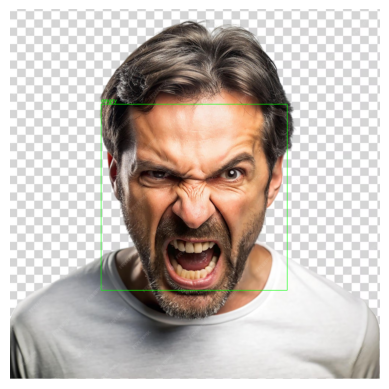

In [17]:
import cv2
from deepface import DeepFace
import matplotlib.pyplot as plt

# load image
img_path = '/content/angry-man-portrait-isolated-transparent-background_220739-95410.avif'
img = cv2.imread(img_path)

# convert for display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# detect face (for drawing box)
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
faces = face_cascade.detectMultiScale(gray, 1.2, 6)

# DeepFace prediction
result = DeepFace.analyze(img_path=img_path, actions=['emotion'], enforce_detection=False)

dominant_emotion = result[0]['dominant_emotion']
print("Dominant Emotion:", dominant_emotion)

# draw results
for (x, y, w, h) in faces:
    cv2.rectangle(img_rgb, (x, y), (x+w, y+h), (0,255,0), 2)
    cv2.putText(img_rgb, dominant_emotion, (x, y-10),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

# show image
plt.imshow(img_rgb)
plt.axis('off')

In [13]:
from deepface import DeepFace

result = DeepFace.analyze(
    img_path = '/content/pexels-olly-789822.jpg',   # change image
    actions = ['emotion']
)

print(result[0]['emotion'])
print("Dominant Emotion:", result[0]['dominant_emotion'])

{'angry': np.float32(0.0004664815), 'disgust': np.float32(9.218664e-06), 'fear': np.float32(0.011775809), 'happy': np.float32(99.53273), 'sad': np.float32(0.0035962), 'surprise': np.float32(0.006514467), 'neutral': np.float32(0.44492057)}
Dominant Emotion: happy


<IPython.core.display.Javascript object>

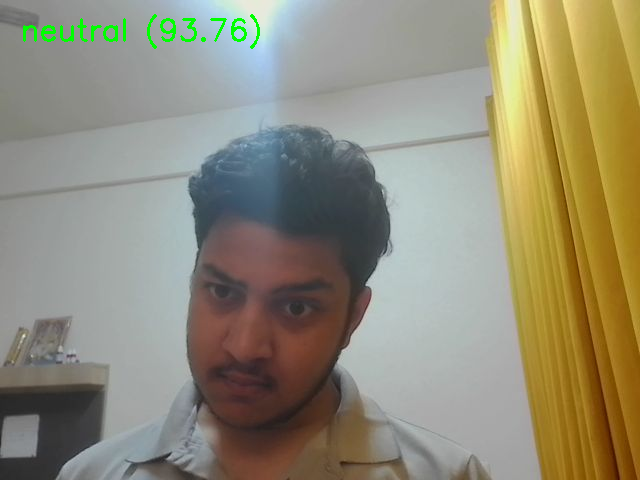

In [27]:
!pip install deepface

import cv2
import numpy as np
from deepface import DeepFace
from IPython.display import display, Javascript
from google.colab.output import eval_js
import base64
from google.colab.patches import cv2_imshow

# ===== CAPTURE IMAGE =====
def capture_image():
    js = Javascript('''
    async function takePhoto() {
        const div = document.createElement('div');
        const button = document.createElement('button');
        button.textContent = 'Capture';
        div.appendChild(button);

        const video = document.createElement('video');
        const stream = await navigator.mediaDevices.getUserMedia({video: true});

        document.body.appendChild(div);
        div.appendChild(video);
        video.srcObject = stream;
        await video.play();

        await new Promise((resolve) => button.onclick = resolve);

        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);

        stream.getTracks().forEach(track => track.stop());
        div.remove();

        return canvas.toDataURL('image/jpeg', 0.8);
    }
    ''')
    display(js)

    data = eval_js('takePhoto()')
    binary = base64.b64decode(data.split(',')[1])
    img = np.frombuffer(binary, dtype=np.uint8)
    return cv2.imdecode(img, cv2.IMREAD_COLOR)

# ===== PREDICT =====
def predict_emotion(img):

    result = DeepFace.analyze(
        img,
        actions=['emotion'],
        enforce_detection=False
    )

    emotion = result[0]['dominant_emotion']
    confidence = result[0]['emotion'][emotion]

    text = f"{emotion} ({confidence:.2f})"

    cv2.putText(img, text, (20,40),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

    return img

# ===== RUN =====
img = capture_image()
output = predict_emotion(img)
cv2_imshow(output)